<a href="https://colab.research.google.com/github/anapontes20/Curso-visao-computacional-Udemy-secao-3/blob/main/Ana_pontes_Se%C3%A7%C3%A3o_3_Vis%C3%A3o_Computacional_O_Guia_Completo_Detec%C3%A7%C3%A3o_de_Faces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **#Visão computacional: RECONHECIMENTO FACIAL**


Reconhecimento facial é o fato do algoritmo conseguir distinguir se aquele rosto é de uma pessoa específica.




##OpenCV

####Carregamento de base de dados e Yale


In [ ]:
from PIL import Image
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
path = "/content/drive/MyDrive/CURSO VISAO COMPUTACIONAL - UDEMY/Visão Computacional Guia Completo/Datasets/yalefaces.zip"
zip_object = zipfile.ZipFile(file=path, mode="r")
zip_object.extractall("./")
zip_object.close()

In [ ]:
import os
print(os.listdir("/content/yalefaces/train"))

['subject03.centerlight.gif', 'subject11.normal.gif', 'subject02.wink.gif', 'subject07.noglasses.gif', 'subject15.surprised.gif', 'subject11.surprised.gif', 'subject07.surprised.gif', 'subject12.wink.gif', 'subject12.sad.gif', 'subject14.sleepy.gif', 'subject08.glasses.gif', 'subject01.glasses.gif', 'subject15.sleepy.gif', 'subject06.glasses.gif', 'subject03.rightlight.gif', 'subject12.sleepy.gif', 'subject08.noglasses.gif', 'subject09.surprised.gif', 'subject12.happy.gif', 'subject13.glasses.gif', 'subject01.wink.gif', 'subject11.centerlight.gif', 'subject05.wink.gif', 'subject10.normal.gif', 'subject14.noglasses.gif', 'subject07.rightlight.gif', 'subject12.noglasses.gif', 'subject09.happy.gif', 'subject07.sleepy.gif', 'subject04.sad.gif', 'subject01.leftlight.gif', 'subject15.centerlight.gif', 'subject04.normal.gif', 'subject02.surprised.gif', 'subject09.sleepy.gif', 'subject05.noglasses.gif', 'subject05.rightlight.gif', 'subject08.leftlight.gif', 'subject06.sleepy.gif', 'subject02.r

In [ ]:
def get_image_data():
  paths = [os.path.join("/content/yalefaces/train", f) for f in os.listdir("/content/yalefaces/train")]
  faces = []
  ids =[]
  for path in paths:
    imagem = Image.open(path).convert("L")
    imagem_np = np.array(imagem, "uint8")
    id = int(os.path.split(path)[1].split(".")[0].replace("subject", ""))
    ids.append(id)
    faces.append(imagem_np)

  return np.array(ids), faces


In [ ]:
ids, faces = get_image_data()

####Treinamento do classificador LBPH


In [ ]:
#!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless
#!pip install opencv-contrib-python

Existem alguns fatores que podem melhorar o treinamento do LBPH

- RAIO/RADIUS: nos consideramos como se existisse uma lupa no pixelq ue queremos identificar, essa lupa gera um raio/circulo ao redor dele. capturando detalhes da imagem, normalmente usamos o numero 1 ou 2, o 1 é mais conservador e o 2 é mais agressivo, essa lupa cobre uma área maior, analisando mais dados, maaaas isso pode fazer com qe ele ignore pixels colados, perdendo um pouco a noção das bordas.

- VIZINHOS/NEIGHBORS: esse fator define quantos pontos de checagem o algoritmo vai coletar dentro do circulo do raio.



In [ ]:

lbph_classifier = cv2.face.LBPHFaceRecognizer_create(radius=4, neighbors=14, grid_x=9, grid_y = 9)
lbph_classifier.train(faces, ids)
lbph_classifier.write("lbph_classifier.yml")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


####Reconhecimento de faces

In [ ]:
lbph_face_classifier = cv2.face.LBPHFaceRecognizer_create()
lbph_face_classifier.read("/content/lbph_classifier.yml")

In [ ]:
imagem_teste = "/content/yalefaces/test/subject10.sad.gif"

array([[130, 130, 130, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 241, 255, 255],
       [255, 255, 255, ..., 234, 237, 252],
       [ 68,  68,  68, ...,  68,  68,  68]], dtype=uint8)
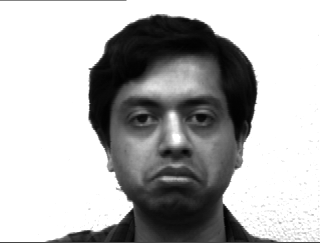

In [ ]:
imagem = Image.open(imagem_teste).convert("L")
imagem_np = np.array(imagem, "uint8")
imagem_np

In [ ]:
previsao = lbph_face_classifier.predict(imagem_np)


In [ ]:
previsao

(10, 36.84750714043355)

In [ ]:
saida_esperada = int(os.path.split(imagem_teste)[1].split(".")[0].replace("subject", ""))
saida_esperada

10

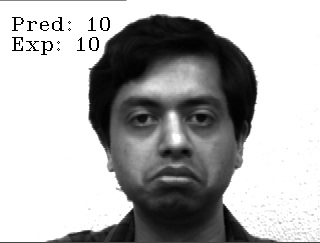

In [ ]:
cv2.putText(imagem_np, "Pred: "+ str(previsao[0]), (10,30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))
cv2.putText(imagem_np, "Exp: "+ str(saida_esperada), (10,50), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))

cv2_imshow(imagem_np)

##Avaliação do classificador


In [ ]:
paths = [os.path.join("/content/yalefaces/test", f) for f in os.listdir("/content/yalefaces/test")]
previsoes = []
saidas_esperadas = []

for path in paths:
  imagem = Image.open(path).convert("L")
  imagem_np = np.array(imagem, "uint8")
  previsao, _ = lbph_face_classifier.predict(imagem_np)
  saida_esperada = int(os.path.split(path)[1].split(".")[0].replace("subject", ""))

  previsoes.append(previsao)
  saidas_esperadas.append(saida_esperada)



In [ ]:
type(previsoes), type(saidas_esperadas)

(list, list)

In [ ]:
previsoes = np.array(previsoes)
saidas_esperadas = np.array(saidas_esperadas)

In [ ]:
type(previsoes), type(saidas_esperadas)

(numpy.ndarray, numpy.ndarray)

In [ ]:
previsoes

array([14,  9, 12,  7,  4, 11,  9,  4,  5,  3, 12, 14,  4, 11,  4,  5,  7,
       13, 15,  7,  8,  4, 14, 12,  1, 10,  6,  4, 13,  3])

In [ ]:
saidas_esperadas

array([14,  7,  2,  7, 10, 11,  9,  1,  5,  3, 12, 14,  4, 11,  8,  5, 15,
       13, 15,  9,  8,  4,  6, 12,  1, 10,  6,  2, 13,  3])

acima nós vemos se as previsoes do algoritmo e as saidas corretas estao batendo, tipo um professor corrigindo a gabarito do aluno, temos alguns erros.

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(saidas_esperadas, previsoes)

0.7

o numero acima é a % de acerto


usamos a Matriz de Confusão é uma tabela que compara os palpites da Inteligência Artificial com as respostas reais.

Ela serve para te mostrar exatamente onde o modelo está acertando e onde ele está se "confundindo".

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(saidas_esperadas, previsoes)
cm

array([[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1]])

<Axes: >

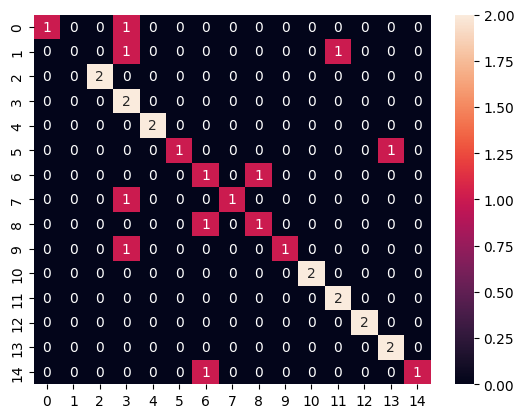

In [ ]:
import seaborn
seaborn.heatmap(cm, annot=True)

#ANTES DE IR PRO DLIB VAMOS ENTENDER A DIFERENÇA ENTRE ELES:

O Dlib é uma biblioteca focada em Detecção de Faces (achar onde está o rosto na foto).

O LBPH é focado em Reconhecimento Facial (saber de quem é aquele rosto que o Dlib achou).

Porém, o Dlib também possui seu próprio método de reconhecimento facial avançado. Se compararmos o Reconhecimento do LBPH contra o Reconhecimento do Dlib, a diferença é o salto tecnológico entre um método matemático clássico e uma Inteligência Artificial moderna.

o processamento do LBPH usa aquela "lupa"para reconhecer os pixels

ja o dlib usa deep learning, ou seja, ele n so olha pros pixels, ele é treinado com varios rostos para entender a anatomia humana.

#DLIB

In [ ]:
import dlib

In [ ]:
detector_face = dlib.get_frontal_face_detector()
detector_pontos = dlib.shape_predictor("/content/drive/MyDrive/CURSO VISAO COMPUTACIONAL - UDEMY/Visão Computacional Guia Completo/Weights/shape_predictor_68_face_landmarks.dat")

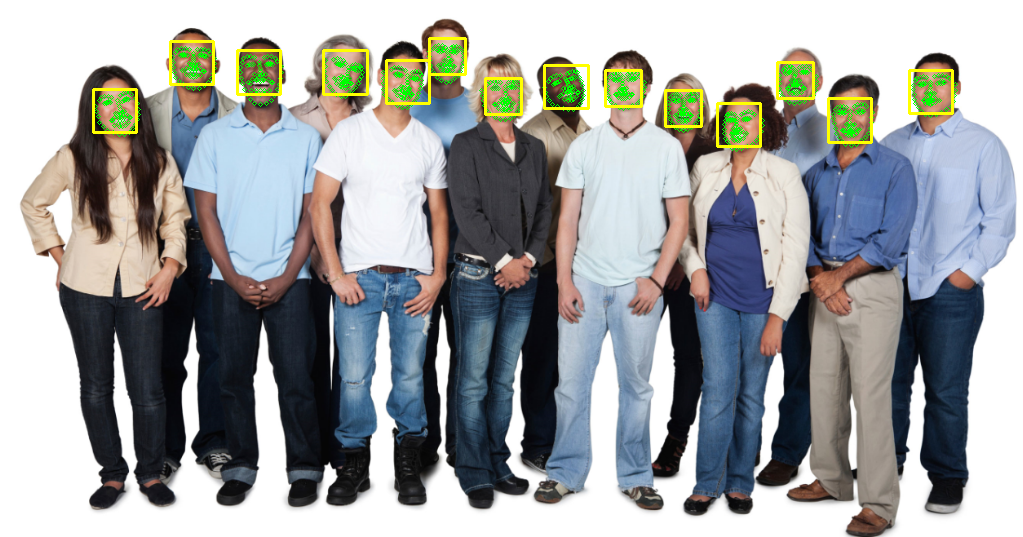

In [ ]:
imagem = cv2.imread("/content/drive/MyDrive/CURSO VISAO COMPUTACIONAL - UDEMY/Visão Computacional Guia Completo/Images/people2.jpg")

deteccoes = detector_face(imagem, 1)
for face in deteccoes:
  pontos = detector_pontos(imagem, face)
  for ponto in pontos.parts():
    cv2.circle(imagem, (ponto.x, ponto.y), 2, (0,255,0), 1)

  l, t, r, b =  face.left(), face.top(), face.right(), face.bottom()
  cv2.rectangle(imagem, (l,t), (r,b), (0,255,255), 2)
cv2_imshow(imagem)

####Detecção de descritores faciais

In [ ]:
detector_face = dlib.get_frontal_face_detector()
detector_pontos = dlib.shape_predictor("/content/drive/MyDrive/CURSO VISAO COMPUTACIONAL - UDEMY/Visão Computacional Guia Completo/Weights/shape_predictor_68_face_landmarks.dat")
descritor_facial_extrator = dlib.face_recognition_model_v1("/content/drive/MyDrive/CURSO VISAO COMPUTACIONAL - UDEMY/Visão Computacional Guia Completo/Weights/dlib_face_recognition_resnet_model_v1.dat")



In [ ]:
index = {}
idx = 0
descritores_faciais = None

paths = [os.path.join("/content/yalefaces/train", f) for f in os.listdir("/content/yalefaces/train")]
for path in paths:
  imagem = Image.open(path).convert("RGB")
  imagem_np = np.array(imagem, "uint8")
  deteccoes = detector_face(imagem_np, 1)
  for face in deteccoes:
    l, t, r, b =  face.left(), face.top(), face.right(), face.bottom()
    cv2.rectangle(imagem_np, (l,t), (r,b), (0,255,255), 2)

    pontos = detector_pontos(imagem_np, face)
    for ponto in pontos.parts():
      cv2.circle(imagem_np, (ponto.x, ponto.y), 2, (0,255,0), 1)

    descritor_facial = descritor_facial_extrator.compute_face_descriptor(imagem_np, pontos)

    descritor_facial = [f for f in descritor_facial]
    descritor_facial = np.array(descritor_facial, dtype=np.float64)
    descritor_facial = descritor_facial[np.newaxis, :]
    #print(descritor_facial.shape)
    #print(descritor_facial)

    if descritores_faciais is None:
      descritores_faciais = descritor_facial
    else:
      descritores_faciais = np.concatenate((descritores_faciais, descritor_facial), axis=0)
    index[idx] = path
    idx += 1


#cv2_imshow(imagem_np)

In [ ]:
descritores_faciais.shape

(132, 128)

In [ ]:
descritores_faciais

array([[-0.14741756,  0.13455944,  0.05091908, ..., -0.11998754,
         0.16568704,  0.10505532],
       [-0.14011335,  0.10662954, -0.04183372, ...,  0.03693167,
         0.09205879,  0.01500822],
       [-0.17026764,  0.08126538, -0.02501782, ..., -0.0118329 ,
         0.03032274,  0.04911824],
       ...,
       [-0.15047085,  0.12347297,  0.08525777, ...,  0.01755363,
         0.09810048,  0.04251372],
       [-0.02567688,  0.08417894,  0.07731017, ..., -0.03971836,
         0.05562052,  0.03638908],
       [-0.097758  ,  0.08243425,  0.01831094, ...,  0.02622219,
         0.05120488,  0.05740112]])

In [ ]:
index

{0: '/content/yalefaces/train/subject03.centerlight.gif',
 1: '/content/yalefaces/train/subject11.normal.gif',
 2: '/content/yalefaces/train/subject02.wink.gif',
 3: '/content/yalefaces/train/subject07.noglasses.gif',
 4: '/content/yalefaces/train/subject15.surprised.gif',
 5: '/content/yalefaces/train/subject11.surprised.gif',
 6: '/content/yalefaces/train/subject07.surprised.gif',
 7: '/content/yalefaces/train/subject12.wink.gif',
 8: '/content/yalefaces/train/subject12.sad.gif',
 9: '/content/yalefaces/train/subject14.sleepy.gif',
 10: '/content/yalefaces/train/subject08.glasses.gif',
 11: '/content/yalefaces/train/subject01.glasses.gif',
 12: '/content/yalefaces/train/subject15.sleepy.gif',
 13: '/content/yalefaces/train/subject06.glasses.gif',
 14: '/content/yalefaces/train/subject03.rightlight.gif',
 15: '/content/yalefaces/train/subject12.sleepy.gif',
 16: '/content/yalefaces/train/subject08.noglasses.gif',
 17: '/content/yalefaces/train/subject09.surprised.gif',
 18: '/content/

####Cálculo da distancia entre as faces

aqui usamos algebra linear para comparar os dados das imagens, quanto menor for o resultado da operacao abaixo, mais proximo esta, como fpoi 0, é a mesma foto!
quanto maior o numero mais difetente as imagens sao

In [ ]:
np.linalg.norm(descritores_faciais[131] - descritores_faciais[131])

np.float64(0.0)

In [ ]:
np.linalg.norm(descritores_faciais[131] - descritores_faciais[130])

np.float64(0.7483596538513665)

para reconhecer a face de alguem especifico eu vou comparar uma imagem com todas as coisas e ver o numeros mais proximos.

In [ ]:
np.linalg.norm(descritores_faciais[0] - descritores_faciais, axis = 1)

array([0.        , 0.78253898, 0.80222378, 0.79148146, 0.58510691,
       0.73379811, 0.79769354, 0.82081697, 0.78161223, 0.67781243,
       0.55869898, 0.76283744, 0.5526994 , 0.7485576 , 0.41645078,
       0.75671024, 0.58672199, 0.64686548, 0.74208299, 0.64439329,
       0.85128045, 0.78625414, 0.73922899, 0.72332298, 0.68092074,
       0.81340586, 0.7735514 , 0.61947433, 0.78740739, 0.71676443,
       0.71391506, 0.55124524, 0.71676443, 0.81383949, 0.60227589,
       0.70765024, 0.49269065, 0.70938923, 0.79577529, 0.80388356,
       0.53718359, 0.67286046, 0.57805597, 0.75400401, 0.78440816,
       0.3796533 , 0.69708647, 0.80049985, 0.82422223, 0.79705832,
       0.70524021, 0.79212564, 0.81021647, 0.70959151, 0.6304216 ,
       0.80701767, 0.79148146, 0.88778592, 0.81049346, 0.61624046,
       0.65607164, 0.70385039, 0.79474702, 0.58526483, 0.41286734,
       0.76462745, 0.7750549 , 0.69981569, 0.79735862, 0.76299129,
       0.56293936, 0.72786403, 0.77983092, 0.57927774, 0.42890

veja que no resultado o primeiro numero é 0, pq é a prorpia imagem que esra rendo referenciada

In [ ]:
np.argmin(np.linalg.norm(descritores_faciais[0] - descritores_faciais[1:], axis = 1) +1)

np.int64(84)

In [ ]:
np.linalg.norm(descritores_faciais[0] - descritores_faciais, axis = 1)[44]

np.float64(0.7844081582895908)

###Deteccão de faces DLIB

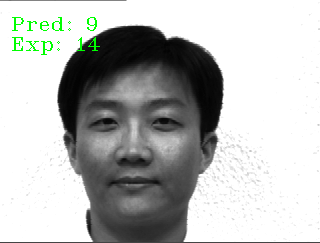

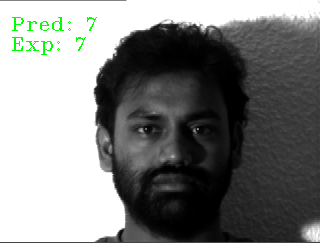

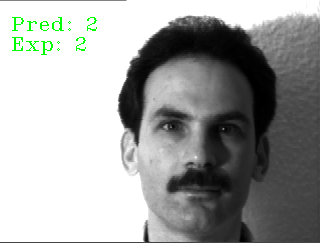

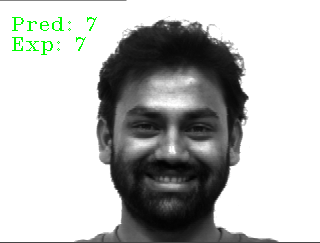

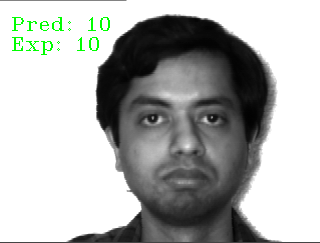

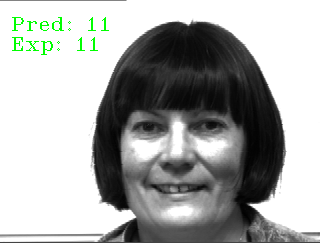

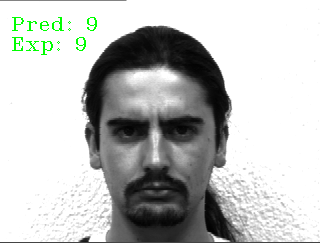

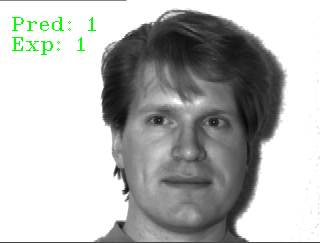

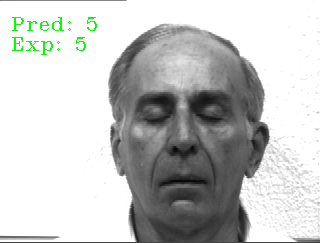

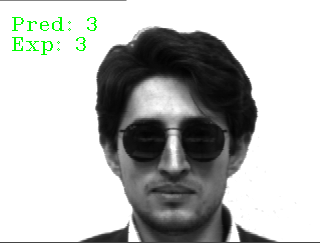

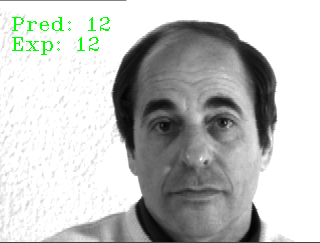

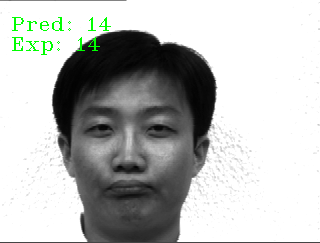

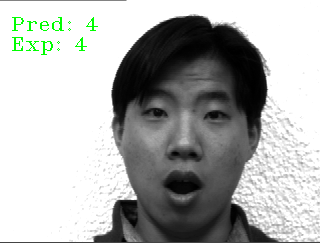

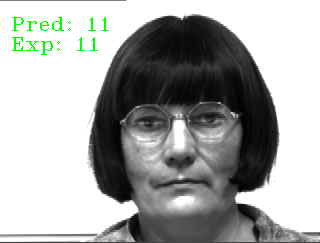

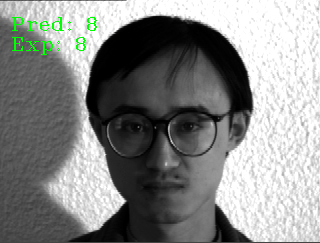

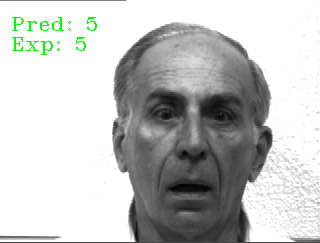

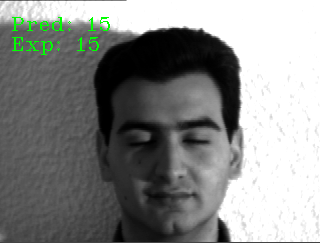

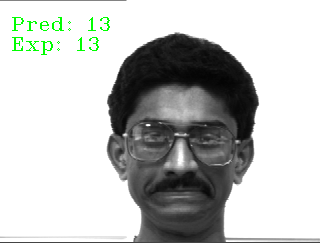

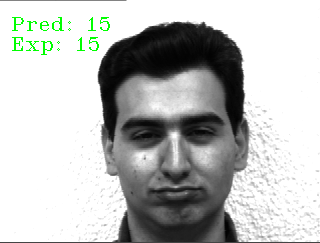

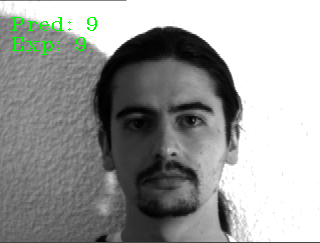

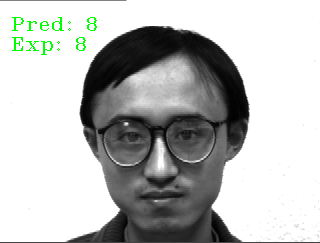

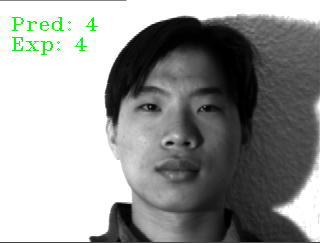

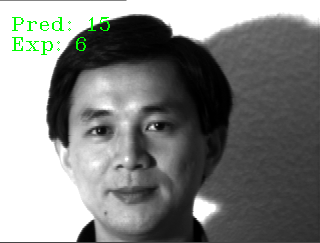

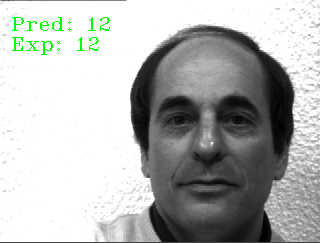

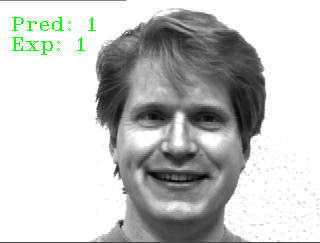

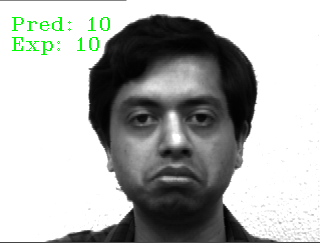

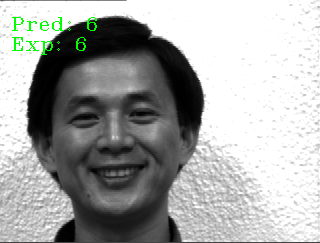

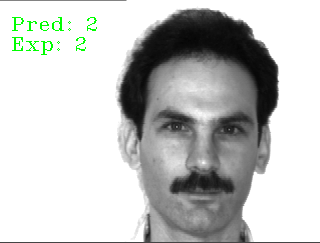

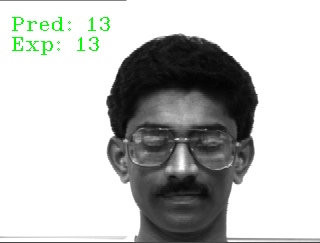

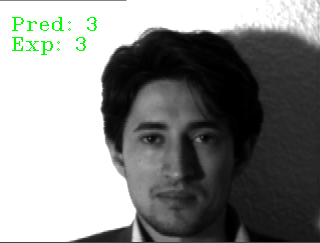

In [ ]:
confianca = 0.8
previsoes = []
saidas_esperadas = []


paths = [os.path.join("/content/yalefaces/test", f) for f in os.listdir("/content/yalefaces/test")]

for path in paths:
  #print(path)
  imagem = Image.open(path).convert("RGB")
  imagem_np = np.array(imagem, "uint8")

  for face in deteccoes:
    pontos = detector_pontos(imagem_np, face)
    descritor_facial = descritor_facial_extrator.compute_face_descriptor(imagem_np, pontos)
    descritor_facial = [f for f in descritor_facial]
    descritor_facial = np.asarray(descritor_facial, dtype=np.float64)
    descritor_facial = descritor_facial[np.newaxis, :]

    distancias = np.linalg.norm(descritor_facial - descritores_faciais, axis =1)
    indice_minimo = np.argmin(distancias)
    distancia_minima = distancias[indice_minimo]

    if distancia_minima <= confianca:
      nome_previsao = int(os.path.split(index[indice_minimo])[1].split(".")[0].replace( "subject", ""))
    else:
      nome_previsao = "Face não identificada"

    nome_real = int(os.path.split(path)[1].split(".")[0].replace( "subject", ""))

    previsoes.append(nome_previsao)
    saidas_esperadas.append(nome_real)

    cv2.putText(imagem_np, "Pred: "+ str(nome_previsao), (10,30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))
    cv2.putText(imagem_np, "Exp: "+ str(nome_real), (10,50), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))

  cv2_imshow(imagem_np)

previsoes = np.array(previsoes)
saidas_esperadas = np.array(saidas_esperadas)

In [ ]:
previsoes

array([ 9,  7,  2,  7, 10, 11,  9,  1,  5,  3, 12, 14,  4, 11,  8,  5, 15,
       13, 15,  9,  8,  4, 15, 12,  1, 10,  6,  2, 13,  3])

In [ ]:
saidas_esperadas

array([14,  7,  2,  7, 10, 11,  9,  1,  5,  3, 12, 14,  4, 11,  8,  5, 15,
       13, 15,  9,  8,  4,  6, 12,  1, 10,  6,  2, 13,  3])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(saidas_esperadas, previsoes)

0.9333333333333333

#**EXERCICIO DE MÓDULO:**

Para testar o algoritmo com outra base de dados, você pode fazer o download do arquivo jones_gabriel.zip que está na pasta Datasets. Nesta pasta existem as minhas imagens e também do Gabriel

Realize o treinamento com o algoritmo LBPH e faça a classificação. Não temos imagens de teste, portanto, você pode usar as mesmas imagens para treinar e testar o algoritmo



###1 passo: extrair o zip do banco de dados e preparar as imagens(extrai-las)

In [ ]:
import zipfile
import os

path = "/content/drive/MyDrive/CURSO VISAO COMPUTACIONAL - UDEMY/Visão Computacional Guia Completo/Datasets/jones_gabriel.zip"
zip_object = zipfile.ZipFile(file=path, mode="r")
zip_object.extractall("./")
zip_object.close()

In [ ]:
print(os.listdir("/content/jones_gabriel"))

['person.1.15.jpg', 'person.1.17.jpg', 'person.2.1.jpg', 'person.1.25.jpg', 'person.2.3.jpg', 'person.1.2.jpg', 'person.2.16.jpg', 'person.1.11.jpg', 'person.2.21.jpg', 'person.2.2.jpg', 'person.1.20.jpg', 'person.1.22.jpg', 'person.1.7.jpg', 'person.1.3.jpg', 'person.2.4.jpg', 'person.1.1.jpg', 'person.1.6.jpg', 'person.1.21.jpg', 'person.2.11.jpg', 'person.2.17.jpg', 'person.2.24.jpg', 'person.2.5.jpg', 'person.2.8.jpg', 'person.1.24.jpg', 'person.1.9.jpg', 'person.2.22.jpg', 'person.1.5.jpg', 'person.2.12.jpg', 'person.1.13.jpg', 'person.1.8.jpg', 'person.1.4.jpg', 'person.2.25.jpg', 'person.2.19.jpg', 'person.2.10.jpg', 'person.1.16.jpg', 'person.2.6.jpg', 'person.1.23.jpg', 'person.2.15.jpg', 'person.1.18.jpg', 'person.1.19.jpg', 'person.2.7.jpg', 'person.2.18.jpg', 'person.2.9.jpg', 'person.1.12.jpg', 'person.2.23.jpg', 'person.2.14.jpg', 'person.1.10.jpg', 'person.1.14.jpg', 'person.2.20.jpg', 'person.2.13.jpg']


agora vamos fazer uma função para extrair o ID de cada pessoa e devolver as imagens e seus receptivos rótulos para treinar o algoritmo

In [ ]:
nome = "person.2.15.jpg"

print(nome.split("."))

##o numero 2 do nome da imagem é o ID da imagem, precisamos dele, no codigo abaixo vamos extrai-lo.

['person', '2', '15', 'jpg']


In [ ]:
def get_image_data():
  paths = [os.path.join("/content/jones_gabriel", f) for f in os.listdir("/content/jones_gabriel")]
  faces = []
  ids = []
  for path in paths:
    imagem = Image.open(path).convert("L")
    imagem_np = np.array(imagem, "uint8")
    id = int(os.path.split(path)[1].split(".")[1].replace("subject", ""))
    ids.append(id)
    faces.append(imagem_np)

  return np.array(ids), faces

In [ ]:
ids, face = get_image_data()

In [ ]:
ids

array([1, 1, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2,
       2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 2, 1, 2, 1, 2, 1, 1, 2, 2, 2, 1,
       2, 2, 1, 1, 2, 2])

In [ ]:
faces

[array([[ 19,  19,  20, ...,  90,  96, 100],
        [ 19,  20,  21, ...,  85,  94, 101],
        [ 20,  21,  22, ...,  79,  93, 104],
        ...,
        [ 16,  18,  20, ...,  49,  64,  58],
        [ 17,  19,  21, ...,  46,  59,  52],
        [ 18,  20,  22, ...,  41,  54,  47]], dtype=uint8),
 array([[16, 17, 19, ..., 77, 81, 84],
        [17, 17, 19, ..., 76, 79, 81],
        [17, 17, 18, ..., 75, 78, 78],
        ...,
        [18, 18, 18, ..., 36, 51, 75],
        [19, 18, 18, ..., 35, 54, 83],
        [17, 18, 18, ..., 31, 52, 83]], dtype=uint8),
 array([[ 18,  20,  21, ..., 139, 140, 142],
        [ 18,  18,  19, ..., 140, 140, 142],
        [ 18,  17,  17, ..., 140, 140, 140],
        ...,
        [107, 108, 108, ..., 132, 132, 131],
        [108, 108, 108, ..., 133, 132, 131],
        [108, 108, 107, ..., 133, 133, 132]], dtype=uint8),
 array([[ 16,  15,  15, ..., 102, 110, 110],
        [ 15,  15,  16, ...,  98, 104, 103],
        [ 16,  16,  17, ...,  96, 100, 100],
       

agora que ja tiramos os IDS das imagens vamos treinar o algoritmo.

In [ ]:
lbph_classifier = cv2.face.LBPHFaceRecognizer_create()
lbph_classifier.train(faces,ids)
lbph_classifier.write("lbph_jonesegabriel_yml")

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


agora vamos para o reconhecimento facial

In [ ]:
lbph_face_classifier = cv2.face.LBPHFaceRecognizer_create()
lbph_classifier.train(faces,ids)
lbph_classifier.write("/content/lbph_jonesegabriel_yml")


In [ ]:
lbph_face_classifier = cv2.face.LBPHFaceRecognizer_create()
lbph_face_classifier.read("/content/lbph_jonesegabriel_yml")

vamos avaliar o classificador agora

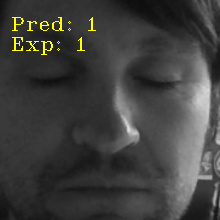

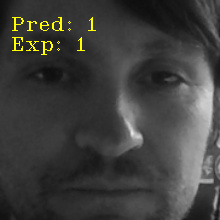

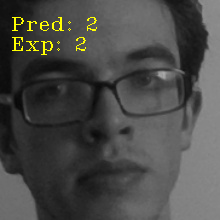

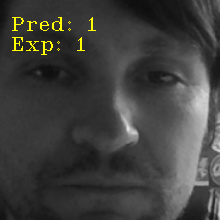

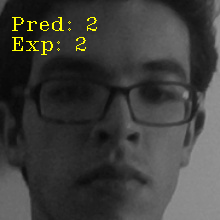

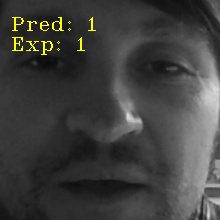

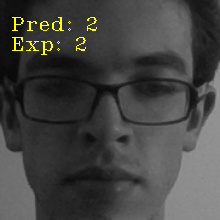

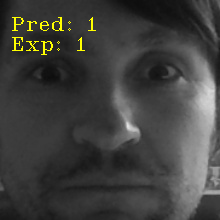

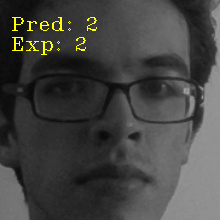

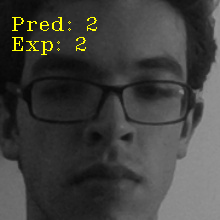

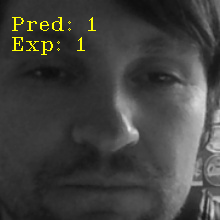

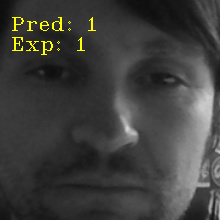

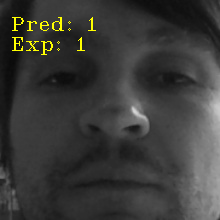

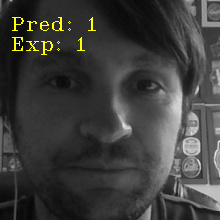

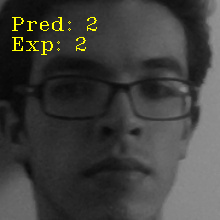

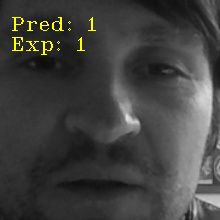

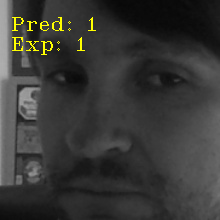

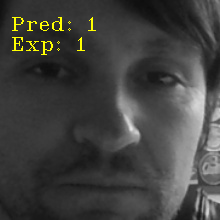

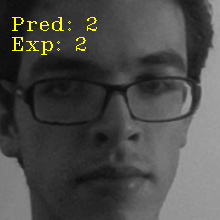

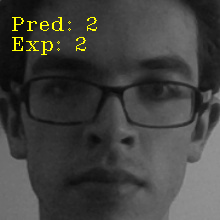

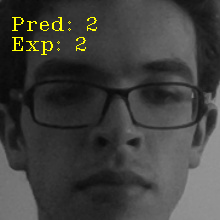

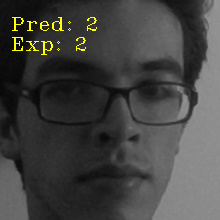

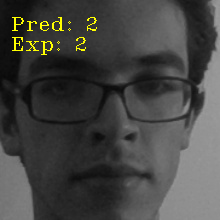

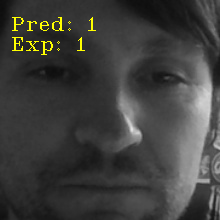

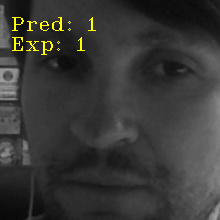

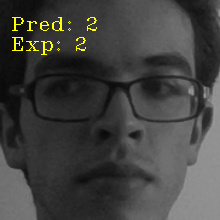

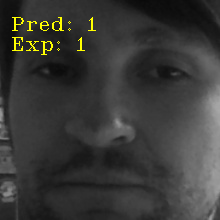

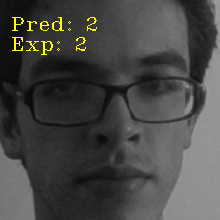

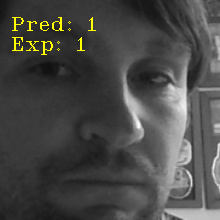

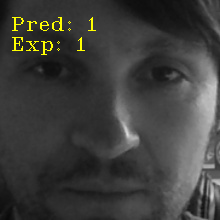

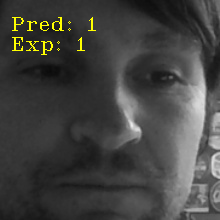

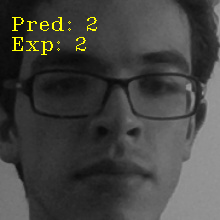

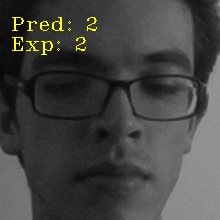

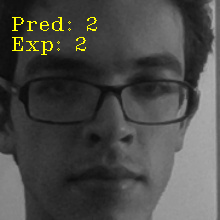

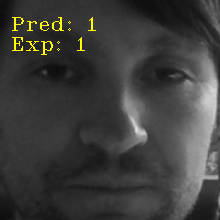

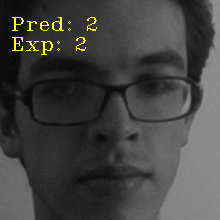

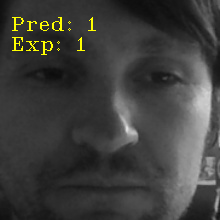

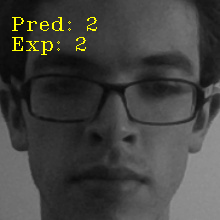

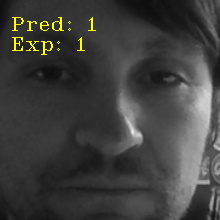

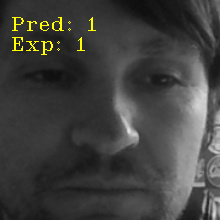

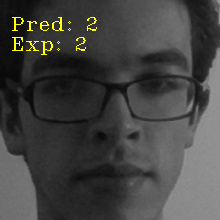

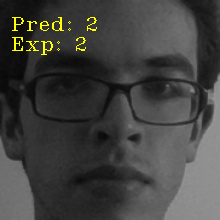

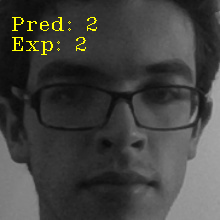

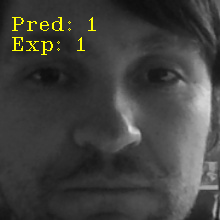

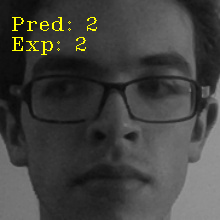

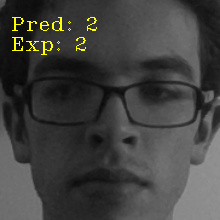

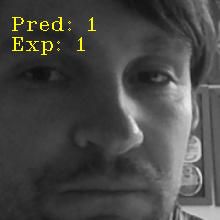

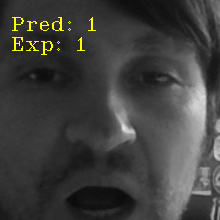

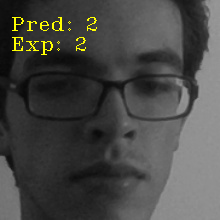

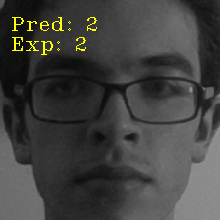

In [ ]:
paths = [os.path.join("/content/jones_gabriel", f) for f in os.listdir("/content/jones_gabriel")]

for path in paths:
  imagem = Image.open(path).convert("L")
  imagem_np = np.array(imagem, "uint8")
  previsao, _ = lbph_face_classifier.predict(imagem_np)
  saida_esperada = int(os.path.split(path)[1].split(".")[1].replace("subject", ""))

  imagem_colorida = cv2.cvtColor(imagem_np,cv2.COLOR_GRAY2BGR)


  cv2.putText(imagem_colorida, "Pred: "+ str(previsao), (10,30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1,(0,255,255))
  cv2.putText(imagem_colorida, "Exp: "+ str(saida_esperada), (10,50), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1,(0,255,255))
  cv2_imshow(imagem_colorida)
